In [1]:
import numpy as np
import matplotlib.pylab as plt
from src.assay_calibration.fit_utils.fit import thresholds_from_prior

In [75]:


def get_monotonic_segments(score_range, log_lrPlus):
    score_range = np.array(score_range)
    diff_signs = np.sign(np.diff(log_lrPlus))
    diff_signs = np.concatenate(([diff_signs[0]],
                                 diff_signs))
    direction = diff_signs[0]
    segments = [score_range[0],]
    segment_indices = [0,]
    for pointIdx,dir in zip(range(len(score_range) - 1),diff_signs[1:]):
        point = score_range[pointIdx]
        if direction == 0 and dir != 0:
            direction = dir
        elif ((direction + dir) == 0) and ((direction * dir) != 0):
            segments.append(point)
            segment_indices.append(pointIdx)
            direction = dir
        
    if segments[-1] != score_range[-1]:
        segments.append(score_range[-1])
        segment_indices.append(len(score_range)-1)
    segments = [s.item() for s in segments]
    return list(zip(segments[:-1],segments[1:])),list(zip(segment_indices[:-1],segment_indices[1:]))
    

In [118]:
lrPlus_path = np.array([1,2,4,8,10])
lrPlus_ben = -lrPlus_path

empirical_lrPlus = np.array([11,10,9,8,7,6,5,4,3,2,1,0,0,-1,-2,-3,-2,-1.5,])
empirical_lrPlus *= -1
scores = 10 + np.arange(len(empirical_lrPlus))

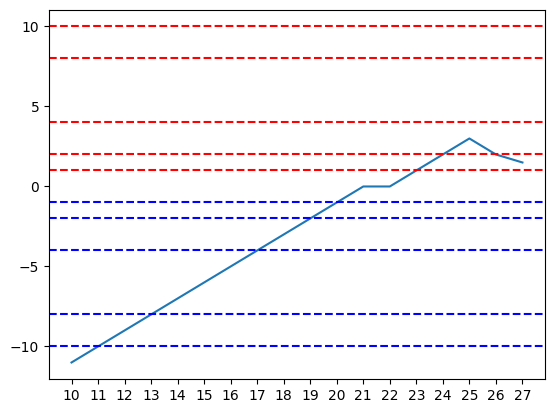

In [119]:
plt.plot(scores, empirical_lrPlus)
[plt.axhline(lr,color='red',linestyle='--') for lr in lrPlus_path]
[plt.axhline(lr,color='blue',linestyle='--') for lr in lrPlus_ben]
_ = plt.xticks(scores, [str(s) for s in scores])

In [120]:
def getPointRanges(scores , lrPlusLow, lrPlusHigh, tauP, tauB):
    _, pathogenic_segment_indices = get_monotonic_segments(scores, lrPlusLow)
    _, benign_segment_indices = get_monotonic_segments(scores, lrPlusHigh)
    pathogenic_ranges = {}
    benign_ranges = {}
    for idxStart, idxEnd in pathogenic_segment_indices:
        ranges_p = get_pathogenic_point_ranges(scores[idxStart:idxEnd+1],
                                                  lrPlusLow[idxStart:idxEnd+1],
                                                  tauP,
                                                  lrPlusLow[idxEnd] > lrPlusLow[idxStart])
        for pointVal, pointRange in ranges_p.items():
            if pointVal not in pathogenic_ranges:
                pathogenic_ranges[pointVal] = [pointRange,]
            else:
                pathogenic_ranges[pointVal].append(pointRange)
    for idxStart, idxEnd in benign_segment_indices:
        ranges_b = get_benign_point_ranges(scores[idxStart:idxEnd+1],
                                           lrPlusHigh[idxStart:idxEnd+1],
                                           tauB,
                                           lrPlusHigh[idxEnd] > lrPlusHigh[idxStart])
        for pointVal, pointRange in ranges_b.items():
            if pointVal not in benign_ranges:
                benign_ranges[pointVal] = [pointRange,]
            else:
                benign_ranges[pointVal].append(pointRange)
    return pathogenic_ranges, benign_ranges

def get_pathogenic_point_ranges(scores, lrPlus, tauP, increasing):
    thresholdsP = np.ones(len(tauP),float) * np.nan # type: ignore
    # Get the first point that is greater than the pathogenic LR+ threshold
    for pointIdx, tau in list(zip(range(len(tauP)),tauP)):
        for si, li in list(zip(scores, lrPlus if increasing else lrPlus))[::1 if increasing else -1]:
            if li >= tau:
                thresholdsP[pointIdx] = si
                break
    point_ranges = {}
    pointScoreP = list(zip([1,2,3,4,8],
                               thresholdsP))[::-1]
    if increasing:
        range_end = scores[-1]
        print(range_end)
        for points, range_start in pointScoreP:
            if not np.isnan(range_start):
                point_ranges[points] = (range_start,range_end)
                range_end = range_start
    else:
        range_start = scores[0]
        for points, range_end in pointScoreP:
            if not np.isnan(range_end):
                point_ranges[points] = (range_start, range_end)
                range_start = range_end
    return {k: (float(i.item()),float(j.item())) for k,(i,j) in point_ranges.items()}

def get_benign_point_ranges(scores, lrPlus, tauB, increasing):
    thresholdsB = np.ones(len(tauB),float) * np.nan
    for pointIdx, tau in list(zip(range(len(tauB)), tauB)):
        for si, li in list(zip(scores, lrPlus))[::-1 if increasing else 1]:
            if li <= tau:
                thresholdsB[pointIdx] = si
                break
    point_ranges = {}
    pointScoreB = list(zip([-1,-2,-3,-4,-8],
                               thresholdsB))[::-1]
    print(pointScoreB)
    if increasing:
        range_start = scores[0]
        for points, range_end in pointScoreB:
            if not np.isnan(range_end):
                point_ranges[points] = (range_start,range_end)
                range_start = range_end
    else:
        range_end = scores[-1]
        for points, range_start in pointScoreB:
            if not np.isnan(range_start):
                point_ranges[points] = (range_start, range_end)
                range_end = range_start
    return {k: (float(i.item()),float(j.item())) for k,(i,j) in point_ranges.items()}

In [121]:
getPointRanges(scores,empirical_lrPlus, empirical_lrPlus,lrPlus_path, lrPlus_ben)

25
[(-8, np.float64(11.0)), (-4, np.float64(13.0)), (-3, np.float64(17.0)), (-2, np.float64(19.0)), (-1, np.float64(20.0))]
[(-8, np.float64(nan)), (-4, np.float64(nan)), (-3, np.float64(nan)), (-2, np.float64(nan)), (-1, np.float64(nan))]


({2: [(24.0, 25.0), (25.0, 26.0)], 1: [(23.0, 24.0), (26.0, 27.0)]},
 {-8: [(10.0, 11.0)],
  -4: [(11.0, 13.0)],
  -3: [(13.0, 17.0)],
  -2: [(17.0, 19.0)],
  -1: [(19.0, 20.0)]})

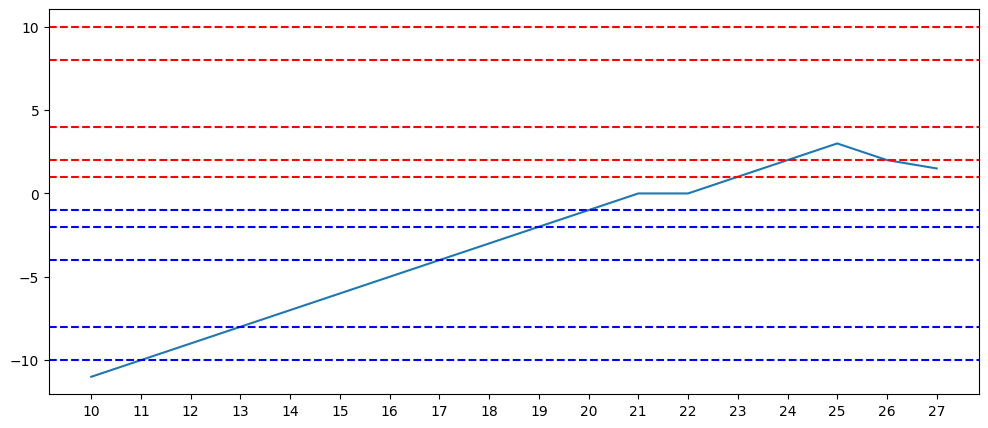

In [122]:
fig,ax = plt.subplots(1,1,figsize=(12,5))
ax.plot(scores, empirical_lrPlus)
[ax.axhline(lr,color='red',linestyle='--') for lr in lrPlus_path]
[ax.axhline(lr,color='blue',linestyle='--') for lr in lrPlus_ben]
_ = ax.set_xticks(scores, [str(s) for s in scores])